# 02 - Compare CNN and feature-RF models

This notebook contains the comparison analysis between the trained feature RF networks and CNNs.

## Inputs

- `inputs/all_channels_results_qc_clean.csv`: frozen CNN and FUCCI-reference MLP metrics.
- `outputs/Result_RF_nuc_imgfdr.csv`: nuclear-image feature RF metrics.
- `outputs/Result_RF_nuc_shapefdr.csv`: nuclear-shape feature RF metrics.
- `outputs/Result_RF_cell_imgfdr.csv`: brightfield feature RF metrics.
- `outputs/Result_RF_cell_shapefdr.csv`: cell-shape feature RF metrics.

The four publication panels are written as PNG files to `figures/outputs/`. The notebook does not write intermediate analysis tables.


In [7]:
from pathlib import Path

import gseapy as gp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib_venn import venn3

ROOT = Path.cwd().resolve()
INPUT_DIR = ROOT / "inputs"
RESULTS_DIR = ROOT / "outputs"
FIGURE_DIR = ROOT / "figures" / RESULTS_DIR.name
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

ALPHA = 0.05
INPUT_FILES = {
    "cnn_mlp": INPUT_DIR / "all_channels_results_qc_clean.csv",
    "rf_nuclear_image": RESULTS_DIR / "Result_RF_nuc_imgfdr.csv",
    "rf_nuclear_shape": RESULTS_DIR / "Result_RF_nuc_shapefdr.csv",
    "rf_cell_image": RESULTS_DIR / "Result_RF_cell_imgfdr.csv",
    "rf_cell_shape": RESULTS_DIR / "Result_RF_cell_shapefdr.csv",
}

MODEL_ROWS = [
    {"model_id": "fucci_mlp", "model_label": "FUCCI reference", "family": "MLP", "modality_id": "fucci_angle", "metric_key": "FUCCI angle", "input_id": "cnn_mlp"},
    {"model_id": "cnn_nuclear_image", "model_label": "CNN: nuclear image", "family": "CNN", "modality_id": "nuclear_image", "metric_key": "Hoechst", "input_id": "cnn_mlp"},
    {"model_id": "cnn_cell_shape", "model_label": "CNN: cell mask", "family": "CNN", "modality_id": "cell_shape", "metric_key": "Segmentation", "input_id": "cnn_mlp"},
    {"model_id": "cnn_nuclear_shape", "model_label": "CNN: nuclear mask", "family": "CNN", "modality_id": "nuclear_shape", "metric_key": "NucleusSegmentation", "input_id": "cnn_mlp"},
    {"model_id": "cnn_cell_image", "model_label": "CNN: brightfield", "family": "CNN", "modality_id": "cell_image", "metric_key": "bf", "input_id": "cnn_mlp"},
    {"model_id": "rf_nuclear_image", "model_label": "RF: nuclear features", "family": "RF", "modality_id": "nuclear_image", "metric_key": "nuc_img_feature", "input_id": "rf_nuclear_image"},
    {"model_id": "rf_cell_shape", "model_label": "RF: cell-shape features", "family": "RF", "modality_id": "cell_shape", "metric_key": "cell_shape_feature", "input_id": "rf_cell_shape"},
    {"model_id": "rf_nuclear_shape", "model_label": "RF: nuclear-shape features", "family": "RF", "modality_id": "nuclear_shape", "metric_key": "nuc_shape_feature", "input_id": "rf_nuclear_shape"},
    {"model_id": "rf_cell_image", "model_label": "RF: brightfield features", "family": "RF", "modality_id": "cell_image", "metric_key": "cell_img_feature", "input_id": "rf_cell_image"},
]
MODEL_MAP = pd.DataFrame(MODEL_ROWS).assign(model_order=range(len(MODEL_ROWS)))

PAIR_ROWS = [
    {"pair_order": 0, "modality_id": "nuclear_image", "modality_label": "Nuclear image", "rf_model_id": "rf_nuclear_image", "cnn_model_id": "cnn_nuclear_image"},
    {"pair_order": 1, "modality_id": "cell_shape", "modality_label": "Cell shape", "rf_model_id": "rf_cell_shape", "cnn_model_id": "cnn_cell_shape"},
    {"pair_order": 2, "modality_id": "nuclear_shape", "modality_label": "Nuclear shape", "rf_model_id": "rf_nuclear_shape", "cnn_model_id": "cnn_nuclear_shape"},
    {"pair_order": 3, "modality_id": "cell_image", "modality_label": "Brightfield", "rf_model_id": "rf_cell_image", "cnn_model_id": "cnn_cell_image"},
]
PAIR_MAP = pd.DataFrame(PAIR_ROWS)

plt.rcParams.update({"font.size": 8, "axes.titlesize": 9, "axes.labelsize": 8})

def save_panel(fig, stem):
    fig.savefig(FIGURE_DIR / f"{stem}.png", dpi=600, bbox_inches="tight", facecolor="white")


## Validate and align model inputs


In [9]:
def load_metrics(path, metric_keys):
    if not path.is_file():
        raise FileNotFoundError(f"Required publication input not found: {path}")
    frame = pd.read_csv(path, header=[0, 1], index_col=0)
    if not isinstance(frame.columns, pd.MultiIndex) or frame.columns.nlevels != 2:
        raise ValueError(f"{path.name}: expected a two-level column header")
    if frame.columns.has_duplicates:
        raise ValueError(f"{path.name}: duplicate metric columns")
    frame.index = frame.index.astype(str)
    if frame.index.has_duplicates or (frame.index.str.strip() == "").any():
        raise ValueError(f"{path.name}: gene identifiers must be unique and non-empty")
    required = [
        (metric, key) for key in metric_keys
        for metric in ("avg_Pearson", "avg_Pearson_fdr")
    ]
    missing = [column for column in required if column not in frame.columns]
    if missing:
        raise ValueError(f"{path.name}: missing required columns {missing}")
    validated = frame.loc[:, required].copy()
    for column in required:
        source = validated[column]
        numeric = pd.to_numeric(source, errors="coerce")
        if (source.notna() & numeric.isna()).any():
            raise ValueError(f"{path.name}: non-numeric values in {column}")
        validated[column] = numeric
    for key in metric_keys:
        if not validated[("avg_Pearson", key)].dropna().between(-1, 1).all():
            raise ValueError(f"{path.name}: Pearson values outside [-1, 1] for {key}")
        if not validated[("avg_Pearson_fdr", key)].dropna().between(0, 1).all():
            raise ValueError(f"{path.name}: q-values outside [0, 1] for {key}")
    return validated.sort_index(kind="mergesort")

cnn_mlp_keys = MODEL_MAP.loc[MODEL_MAP["input_id"].eq("cnn_mlp"), "metric_key"].tolist()
cnn_mlp = load_metrics(INPUT_FILES["cnn_mlp"], cnn_mlp_keys)
comparison_genes = cnn_mlp.index
metric_frames = {"cnn_mlp": cnn_mlp}
for row in MODEL_MAP.loc[MODEL_MAP["family"].eq("RF")].itertuples(index=False):
    metric_frames[row.input_id] = load_metrics(INPUT_FILES[row.input_id], [row.metric_key])



## Significant genes and model-family unions

In [10]:
metric_parts = []
for row in MODEL_MAP.itertuples(index=False):
    source = metric_frames[row.input_id].reindex(comparison_genes)
    metric_parts.append(pd.DataFrame({
        "model_order": row.model_order,
        "model_id": row.model_id,
        "model_label": row.model_label,
        "family": row.family,
        "modality_id": row.modality_id,
        "gene": comparison_genes,
        "source_present": comparison_genes.isin(metric_frames[row.input_id].index),
        "avg_pearson": source[("avg_Pearson", row.metric_key)].to_numpy(),
        "q_value": source[("avg_Pearson_fdr", row.metric_key)].to_numpy(),
    }))
gene_metrics = (
    pd.concat(metric_parts, ignore_index=True)
    .assign(significant=lambda frame: frame["q_value"].lt(ALPHA))
    .sort_values(["model_order", "gene"], kind="mergesort")
    .reset_index(drop=True)
)
absent_rows = gene_metrics.loc[~gene_metrics["source_present"]]
if absent_rows[["avg_pearson", "q_value"]].notna().any().any() or absent_rows["significant"].any():
    raise AssertionError("Absent RF genes must remain non-significant after alignment")
model_counts = (
    gene_metrics.groupby(
        ["model_order", "model_id", "model_label", "family", "modality_id"],
        sort=False,
    )
    .agg(
        n_genes=("gene", "size"),
        n_source_present=("source_present", "sum"),
        n_tested=("q_value", "count"),
        n_significant=("significant", "sum"),
    )
    .reset_index()
    .sort_values("model_order", kind="mergesort")
)
model_gene_sets = {
    model_id: set(group.loc[group["significant"], "gene"])
    for model_id, group in gene_metrics.groupby("model_id", sort=False)
}
cnn_ids = MODEL_MAP.loc[MODEL_MAP["family"].eq("CNN"), "model_id"].tolist()
rf_ids = MODEL_MAP.loc[MODEL_MAP["family"].eq("RF"), "model_id"].tolist()
fucci_genes = model_gene_sets["fucci_mlp"]
cnn_union = set().union(*(model_gene_sets[model_id] for model_id in cnn_ids))
rf_union = set().union(*(model_gene_sets[model_id] for model_id in rf_ids))
fucci_overlap_summary = pd.DataFrame([
    {"comparison": "RF feature union", "fucci_denominator": len(fucci_genes), "overlap_n": len(fucci_genes & rf_union)},
    {"comparison": "CNN union", "fucci_denominator": len(fucci_genes), "overlap_n": len(fucci_genes & cnn_union)},
])
fucci_overlap_summary["overlap_percent"] = (
    100 * fucci_overlap_summary["overlap_n"] / fucci_overlap_summary["fucci_denominator"]
)
fucci_overlap_summary


,comparison,fucci_denominator,overlap_n,overlap_percent
0,RF feature union,253,203,80.237154
1,CNN union,253,180,71.146245


## Figure 5B: overlap of FUCCI, CNN, and feature-model genes


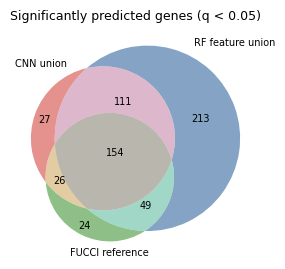

In [11]:
fig, ax = plt.subplots(figsize=(3.2, 3.0))
diagram = venn3(
    subsets=(cnn_union, rf_union, fucci_genes),
    set_labels=("CNN union", "RF feature union", "FUCCI reference"),
    set_colors=("#D95F59", "#4C78A8", "#59A14F"),
    alpha=0.68,
    ax=ax,
)
for text in [*(diagram.set_labels or []), *(diagram.subset_labels or [])]:
    if text is not None:
        text.set_fontsize(7)
ax.set_title("Significantly predicted genes (q < 0.05)")
save_panel(fig, "Fig5B_model_union_overlap")
plt.show()


## Supplementary Figure 5A: significant genes per model


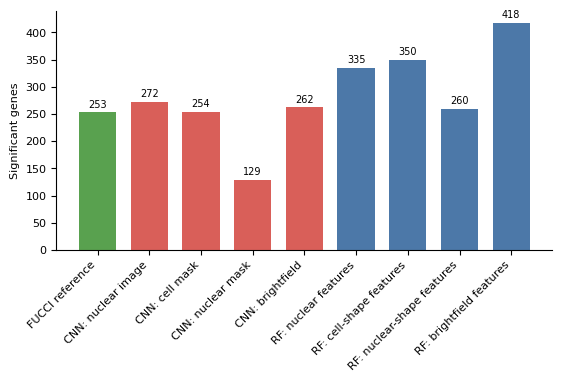

In [12]:
family_colors = {"MLP": "#59A14F", "CNN": "#D95F59", "RF": "#4C78A8"}
plot_counts = model_counts.sort_values("model_order", kind="mergesort")
fig, ax = plt.subplots(figsize=(6.4, 3.1))
bars = ax.bar(
    plot_counts["model_label"], plot_counts["n_significant"],
    color=plot_counts["family"].map(family_colors), width=0.72,
)
ax.bar_label(bars, padding=2, fontsize=7)
ax.set_ylabel("Significant genes")
ax.tick_params(axis="x", rotation=45)
for label in ax.get_xticklabels():
    label.set_ha("right")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(False)
save_panel(fig, "Supplementary_Fig5A_model_counts")
plt.show()


## Supplementary Figure 5B: Reactome 2022 ORA

Each model's significant genes are submitted independently to Enrichr. The panel displays up to three terms per model with adjusted `P < 0.05`; color encodes `-log10(q)` and dot size encodes combined score.


In [13]:
enrichr_columns = [
    "Gene_set", "Term", "Overlap", "P-value", "Adjusted P-value",
    "Odds Ratio", "Combined Score", "Genes",
]
ora_parts = []
for row in MODEL_MAP.itertuples(index=False):
    genes = sorted(model_gene_sets[row.model_id], key=lambda value: (value.casefold(), value))
    result = gp.enrichr(
        gene_list=genes, gene_sets="Reactome_2022", organism="Mouse",
        outdir=None, cutoff=1.0,
    ).results.copy()
    missing = sorted(set(enrichr_columns) - set(result.columns))
    if missing:
        raise ValueError(f"Enrichr schema changed for {row.model_id}; missing {missing}")
    result = result[enrichr_columns].rename(columns={
        "Gene_set": "gene_set", "Term": "term", "Overlap": "overlap",
        "P-value": "p_value", "Adjusted P-value": "q_value",
        "Odds Ratio": "odds_ratio", "Combined Score": "combined_score",
        "Genes": "genes",
    })
    for column in ["p_value", "q_value", "odds_ratio", "combined_score"]:
        result[column] = pd.to_numeric(result[column], errors="raise")
    if not result["q_value"].between(0, 1).all():
        raise ValueError(f"Enrichr returned invalid q-values for {row.model_id}")
    result.insert(0, "model_order", row.model_order)
    result.insert(1, "model_id", row.model_id)
    result.insert(2, "model_label", row.model_label)
    result.insert(3, "query_n", len(genes))
    ora_parts.append(result)

reactome_ora = (
    pd.concat(ora_parts, ignore_index=True)
    .sort_values(["model_order", "q_value", "p_value", "term"], kind="mergesort")
    .reset_index(drop=True)
)
reactome_ora["rank_within_model"] = reactome_ora.groupby("model_id", sort=False).cumcount() + 1
ora_columns = [
    "model_id", "model_label", "query_n", "rank_within_model",
    "gene_set", "term", "overlap", "p_value", "q_value",
    "odds_ratio", "combined_score", "genes",
]
top_reactome = (
    reactome_ora.loc[reactome_ora["q_value"].lt(ALPHA)]
    .groupby("model_id", sort=False, group_keys=False)
    .head(3)
    .copy()
)
if top_reactome.empty or top_reactome.groupby("model_id").size().gt(3).any():
    raise ValueError("Reactome ORA produced an invalid top-three structure")
top_reactome[ora_columns]


,model_id,model_label,query_n,rank_within_model,gene_set,term,overlap,p_value,q_value,odds_ratio,combined_score,genes
0,fucci_mlp,FUCCI reference,253,1,Reactome_2022,"Cell Cycle, Mitotic R-HSA-69278",40/523,4.279013e-20,3.500233e-17,7.489964,334.037258,TOP2A;CDCA8;HMMR;SMC4;CENPA;AURKA;CDC20;CCNB2;...
1,fucci_mlp,FUCCI reference,253,2,Reactome_2022,Cell Cycle Checkpoints R-HSA-69620,30/271,9.851493e-20,4.029261e-17,10.888488,476.524639,CDCA8;CENPA;CDC20;CCNB2;CCNB1;UBB;UBC;SPDL1;BU...
2,fucci_mlp,FUCCI reference,253,3,Reactome_2022,Cell Cycle R-HSA-1640170,43/654,4.572324e-19,1.246720e-16,6.412969,270.813861,TOP2A;CDCA8;HMMR;SMC4;CENPA;AURKA;CDC20;CCNB2;...
818,cnn_nuclear_image,CNN: nuclear image,272,1,Reactome_2022,"Cell Cycle, Mitotic R-HSA-69278",36/523,1.142156e-15,1.002813e-12,6.026833,207.358374,TOP2A;CDKN1A;CDCA8;HMMR;SMC4;CENPA;AURKA;CDC20...
819,cnn_nuclear_image,CNN: nuclear image,272,2,Reactome_2022,RHO GTPases Activate Formins R-HSA-5663220,19/119,2.669302e-15,1.171824e-12,14.740395,494.642844,SEC13;PLK1;CDCA8;KNL1;CENPA;RHOB;CDC20;SGO1;CE...
820,cnn_nuclear_image,CNN: nuclear image,272,3,Reactome_2022,Resolution Of Sister Chromatid Cohesion R-HSA-...,18/106,4.769312e-15,1.329580e-12,15.816034,521.558634,SEC13;PLK1;CDCA8;KNL1;CENPA;CDC20;SGO1;CENPE;C...
1696,cnn_cell_shape,CNN: cell mask,254,1,Reactome_2022,Cell Cycle Checkpoints R-HSA-69620,28/271,1.232555e-17,1.080951e-14,9.943625,387.153618,CDKN1A;CDCA8;CDC20;PSMB4;CCNB1;UBB;UBC;SPDL1;B...
1697,cnn_cell_shape,CNN: cell mask,254,2,Reactome_2022,"Cell Cycle, Mitotic R-HSA-69278",36/523,1.252486e-16,5.492151e-14,6.530565,239.124690,TOP2A;CDKN1A;CDCA8;HMMR;SMC4;AURKA;CDC20;PSMB4...
1698,cnn_cell_shape,CNN: cell mask,254,3,Reactome_2022,Cell Cycle R-HSA-1640170,38/654,4.160466e-15,1.216243e-12,5.463414,180.910840,TOP2A;CDKN1A;CDCA8;HMMR;SMC4;AURKA;CDC20;PSMB4...
2573,cnn_nuclear_shape,CNN: nuclear mask,129,1,Reactome_2022,"Cell Cycle, Mitotic R-HSA-69278",17/523,4.581561e-08,3.138369e-05,5.808953,98.163416,TOP2A;CDKN1A;RRM2;UBE2C;CDCA8;PRKCA;SMC4;SGO1;...


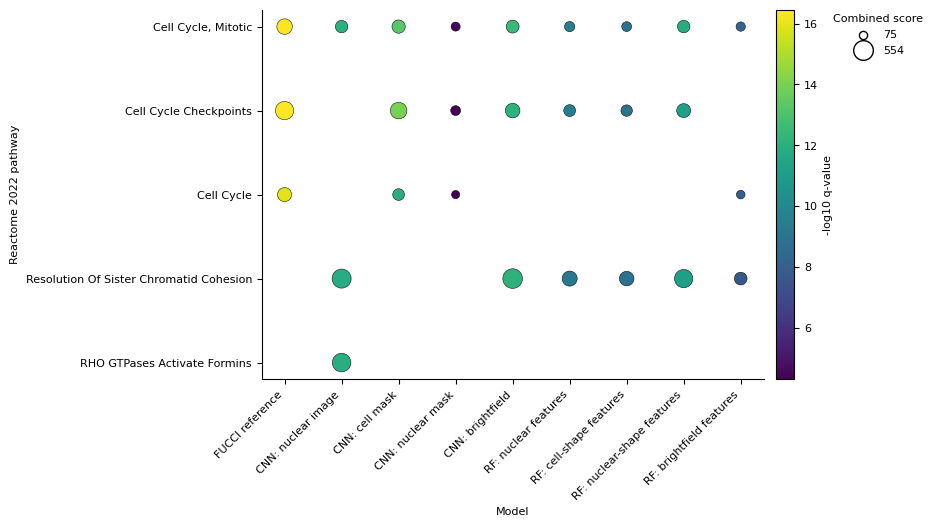

In [7]:
plot_ora = top_reactome.copy()
plot_ora["term_clean"] = plot_ora["term"].str.replace(r"\s+R-HSA-\d+$", "", regex=True)
term_order = (
    plot_ora.groupby("term_clean", sort=False)["q_value"].min()
    .sort_values(kind="mergesort").index.tolist()[::-1]
)
x_lookup = dict(zip(MODEL_MAP["model_id"], MODEL_MAP["model_order"]))
y_lookup = dict(zip(term_order, range(len(term_order))))
plot_ora["x"] = plot_ora["model_id"].map(x_lookup)
plot_ora["y"] = plot_ora["term_clean"].map(y_lookup)
plot_ora["minus_log10_q"] = -np.log10(plot_ora["q_value"].clip(lower=np.finfo(float).tiny))
score_min = plot_ora["combined_score"].min()
score_max = plot_ora["combined_score"].max()
if score_max == score_min:
    dot_sizes = np.full(len(plot_ora), 90.0)
else:
    dot_sizes = 35 + 165 * (plot_ora["combined_score"] - score_min) / (score_max - score_min)

fig, ax = plt.subplots(figsize=(7.8, 4.8))
scatter = ax.scatter(
    plot_ora["x"], plot_ora["y"], c=plot_ora["minus_log10_q"], s=dot_sizes,
    cmap="viridis", edgecolors="black", linewidths=0.35,
)
ax.set_xticks(MODEL_MAP["model_order"], MODEL_MAP["model_label"], rotation=45, ha="right")
ax.set_yticks(range(len(term_order)), term_order)
ax.set_xlabel("Model")
ax.set_ylabel("Reactome 2022 pathway")
colorbar = fig.colorbar(scatter, ax=ax, pad=0.02)
colorbar.set_label("-log10 q-value")
size_values = [score_min, score_max]
size_handles = [
    ax.scatter([], [], s=size, facecolor="white", edgecolor="black")
    for size in (35, 200)
]
ax.legend(
    size_handles, [f"{value:.0f}" for value in size_values],
    title="Combined score", frameon=False, loc="upper left",
    bbox_to_anchor=(1.13, 1), borderaxespad=0,
)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(False)
save_panel(fig, "Supplementary_Fig5B_Reactome_2022_ORA")
plt.show()


## Supplementary Figure 5C: modality-paired RF and CNN genes

Each stacked bar partitions significant genes into RF feature-only, shared, and CNN-only sets for a matched image modality.


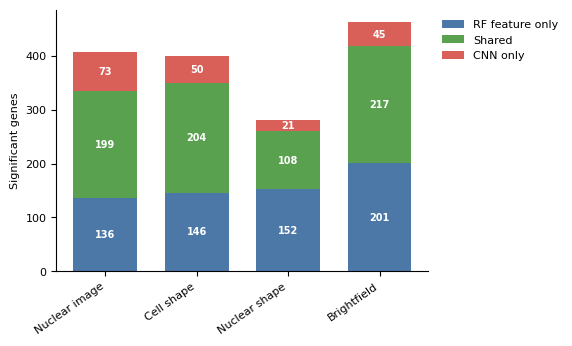

,modality_id,modality_label,rf_model_id,cnn_model_id,feature_only,shared,cnn_only
0,nuclear_image,Nuclear image,rf_nuclear_image,cnn_nuclear_image,136,199,73
1,cell_shape,Cell shape,rf_cell_shape,cnn_cell_shape,146,204,50
2,nuclear_shape,Nuclear shape,rf_nuclear_shape,cnn_nuclear_shape,152,108,21
3,cell_image,Brightfield,rf_cell_image,cnn_cell_image,201,217,45


In [14]:
modality_rows = []
for pair in PAIR_MAP.sort_values("pair_order").itertuples(index=False):
    feature_set = model_gene_sets[pair.rf_model_id]
    cnn_set = model_gene_sets[pair.cnn_model_id]
    modality_rows.append({
        "pair_order": pair.pair_order,
        "modality_id": pair.modality_id,
        "modality_label": pair.modality_label,
        "rf_model_id": pair.rf_model_id,
        "cnn_model_id": pair.cnn_model_id,
        "feature_only": len(feature_set - cnn_set),
        "shared": len(feature_set & cnn_set),
        "cnn_only": len(cnn_set - feature_set),
    })
modality_counts = pd.DataFrame(modality_rows).sort_values("pair_order", kind="mergesort")
colors = {"feature_only": "#4C78A8", "shared": "#59A14F", "cnn_only": "#D95F59"}
labels = {"feature_only": "RF feature only", "shared": "Shared", "cnn_only": "CNN only"}
fig, ax = plt.subplots(figsize=(4.8, 3.4))
bottom = np.zeros(len(modality_counts), dtype=float)
for section in ["feature_only", "shared", "cnn_only"]:
    values = modality_counts[section].to_numpy()
    bars = ax.bar(
        modality_counts["modality_label"], values, bottom=bottom,
        color=colors[section], label=labels[section], width=0.7,
    )
    for bar, value, base in zip(bars, values, bottom):
        if value > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2, base + value / 2, str(value),
                ha="center", va="center", fontsize=7, color="white",
                fontweight="bold",
            )
    bottom += values
ax.set_ylabel("Significant genes")
ax.tick_params(axis="x", rotation=35)
for label in ax.get_xticklabels():
    label.set_ha("right")
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1))
ax.spines[["top", "right"]].set_visible(False)
ax.grid(False)
save_panel(fig, "Supplementary_Fig5C_modality_feature_CNN_counts")
plt.show()
modality_counts.drop(columns="pair_order")
